In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from datetime import datetime

In [2]:
def Cindex_2_num(string):
    '''
    Convert string quarters to datetime  (四季度--12.1)
    '''
    year = int(string[:4])
    if '一' in string:
        month = 3
    elif '中' in string:
        month = 6
    elif '三' in string:
        month = 9
    else:
        month = 12
    return datetime(year, month,1)
def clean_data(df):
    stock_codes = df.iloc[:, 0:3]
    stock_codes.columns = stock_codes.columns.droplevel(0)
    stock_codes = stock_codes.rename_axis(None, axis=1)
    df = df.drop(df.columns[0:3], axis=1)
    # 将宽面板数据转换为长面板数据
    df = df.stack(level=0).reset_index(level=1).rename(columns={'level_1': 'Date'}).reset_index(drop=True)

    # 重复股票代码，使其与转换后的长面板数据具有相同的行数
    stock_codes_repeated = stock_codes.loc[stock_codes.index.repeat(len(df['Date'].unique()))].reset_index(drop=True)

    # 将股票代码与长面板数据合并
    df = pd.concat([stock_codes_repeated, df], axis=1)
    df = df.replace('--', float('nan'))
    df = df.dropna(subset=['季度持仓变动(万股)', '季度持仓变动比例(%)', '持有基金数',
       '持股占流通股比(%)', '持股市值占基金净值比(%)', '持股市值占基金股票投资市值比(%)', '持股总市值(万元)',
       '持股总量(万股)'])
    df.Date = df.Date.apply(Cindex_2_num)
    return df

In [3]:
data = clean_data( pd.read_excel(r'E:\behavioral finance\data\2003-2005.xlsx', header=[0, 1]) )
for ti in range(2006,2023,3):
    url = 'E:\\behavioral finance\\data\\' + str(ti)+'-'+str(ti+2)+ '.xlsx'
    data = pd.concat([data,  clean_data(  pd.read_excel(url, header=[0, 1]) )])

In [31]:
data

,代码,所属行业,名称,Date,持有基金数,持股总量(万股),季度持仓变动(万股),季度持仓变动比例(%),持股占流通股比(%),持股总市值(万元),持股市值占基金净值比(%),持股市值占基金股票投资市值比(%)
5,000001.SZ,银行,平安银行,2004-09-01,2.0,1135.3450,131.7941,13.1328,0.805574,9264.415200,1.989919,2.613135
6,000001.SZ,银行,平安银行,2004-06-01,2.0,1003.5509,220.5177,28.1620,0.712060,8630.537740,2.117727,2.831209
7,000001.SZ,银行,平安银行,2004-12-01,3.0,1735.0955,599.7505,52.8254,1.231121,11434.279345,1.842174,2.060637
8,000001.SZ,银行,平安银行,2005-03-01,1.0,427.4503,-1307.6452,-75.3645,0.303293,2227.016063,3.003754,3.976532
9,000001.SZ,银行,平安银行,2005-09-01,2.0,1264.1585,-490.0720,-27.9366,0.896972,7281.552960,1.926731,2.058382
...,...,...,...,...,...,...,...,...,...,...,...,...
56576,9995.HK,医药生物,荣昌生物,2023-03-01,4.0,660.6000,-3.2179,-0.4848,1.888362,24201.681156,3.514241,3.939863
56577,9995.HK,医药生物,荣昌生物,2023-09-01,20.0,1645.4000,622.4000,60.8407,4.703467,60842.460987,2.355887,4.632515
56578,9995.HK,医药生物,荣昌生物,2023-06-01,7.0,1023.0000,362.4000,54.8592,2.924302,32304.104746,2.604029,3.537872
56579,9995.HK,医药生物,荣昌生物,2023-12-01,22.0,1444.0000,-201.4000,-12.2402,4.127754,49006.476660,2.295603,4.565860


In [4]:
def HHI(df):
    '''
    Herfindahl-Hirschman Index : a common measure of market concentration
    '''
    df['market_share'] = df['持股总市值(万元)']/sum(df['持股总市值(万元)'])
    return sum(df['market_share']**2)
hhi = data.groupby('Date').apply(HHI).sort_index()
def Sum_of_wealth(df):
    '''
    Market value per holding
    '''
    return sum(df['持股总市值(万元)'])/ sum(df['持有基金数'])
FundWealth = data.groupby('Date').apply(Sum_of_wealth).sort_index()
def Num_in_top(df):
    '''
    the number of mutual fund heavily hold top 10 stocks / total number of mutual fund
    '''
    return sum(df.nlargest(10, "持有基金数")['持有基金数'])/sum(df['持有基金数'])
numTop = data.groupby('Date').apply(Num_in_top).sort_index()
# Assuming 'hhi' and 'numTop' are your data series or arrays.
# Convert them to pandas DataFrame and set appropriate column names.
df_hhi = pd.DataFrame(hhi).rename(columns={0: 'HS2'})
df_numTop = pd.DataFrame(numTop).rename(columns={0: 'HS1'})
df_hhi.index = df_hhi.index + pd.offsets.MonthEnd(0)
df_numTop.index = df_numTop.index + pd.offsets.MonthEnd(0)

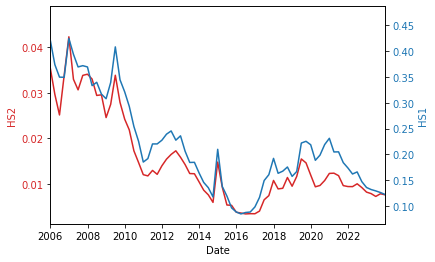

In [5]:
# Create a new figure and axis object.
fig, ax1 = plt.subplots()

# Plot the first data series 'HS2' against its own Y axis.
color = 'tab:red'
ax1.set_xlabel('Date')
ax1.set_ylabel('HS2', color=color)
ax1.plot(df_hhi.index, df_hhi['HS2'], color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xlim(pd.Timestamp('2006-01-01'), pd.Timestamp('2023-12-31'))

# Create a second Y axis object that shares the same X axis.
ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('HS1', color=color)
ax2.plot(df_numTop.index, df_numTop['HS1'], color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.show()

### plot CSI 300 index 

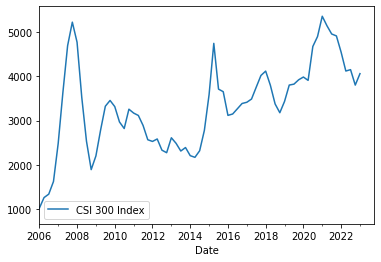

In [6]:
ind_data = pd.read_excel(r'E:\behavioral finance\data\hs_index.xls')
hs300  = ind_data[ind_data['指数代码_IdxCd']==300][['Date','Price']].set_index('Date')
hs300_quarterly = hs300.resample('Q').mean()
ax = hs300_quarterly.plot()
ax.set_xlim(left=pd.Timestamp('2006-01-01'), right=pd.Timestamp('2023-12-31'))

# Renaming the label.
ax.legend(["CSI 300 Index"])

ax.set_xlabel("Date")
#ax.set_ylabel("Index Value")

plt.show()

Herding Periodics, stocks that more than 100 mutual fund hold 

 剔除好公司？ 不能区分herding 和 分析师能力

## loading 25 ff data

In [7]:
# Define the path to your Excel file
file_path = r'E:\behavioral finance\data\FF_25.xls'
df = pd.read_excel(file_path)
df = df[df['交易所标识_Exchflg']==0]
df=df.drop(columns=['交易所标识_Exchflg','样本容量()_SampSize'])
# Ensure the Date column is in datetime format
df['日期_Date'] = pd.to_datetime(df['日期_Date'])

# Setting the date as the index
df.set_index('日期_Date', inplace=True)

# A function to calculate quarterly returns
def quarterly_returns(group):
    # Converting monthly returns to "1 + monthly return" format
    group['资产组合月收益率__流通市值加权_Pmonret_tmv'] = 1 + group['资产组合月收益率__流通市值加权_Pmonret_tmv']#/100
    group['资产组合月收益率__总市值加权_Pmonret_mc'] = 1 + group['资产组合月收益率__总市值加权_Pmonret_mc']#/100
    
    # Resampling to quarterly, calculating the product (compounded return), then subtracting 1
    quarterly = group.resample('Q').prod() - 1
    
    return quarterly

# Grouping by market, size, and book-to-market ratio, then applying the function
quarterly_FF_25 = df.groupby(['市场标识_Mktflg', '规模标识_Sizeflg', '账面市值比标识_BMflg']).apply(quarterly_returns)

# Resetting index if necessary
quarterly_FF_25.reset_index(inplace=True)

# Now `quarterly_data` contains the quarterly returns, grouped as requested
print(quarterly_FF_25.head())

  市场标识_Mktflg  规模标识_Sizeflg  账面市值比标识_BMflg    日期_Date  \
0           A             1              1 2006-09-30   
1           A             1              1 2006-12-31   
2           A             1              1 2007-03-31   
3           A             1              1 2007-06-30   
4           A             1              1 2007-09-30   

   资产组合月收益率__流通市值加权_Pmonret_tmv  资产组合月收益率__总市值加权_Pmonret_mc  
0                      0.075942                    0.101710  
1                     -0.034604                   -0.044650  
2                      0.880380                    0.837471  
3                      0.244380                    0.213574  
4                      0.502499                    0.690274  


In [8]:
# Sample code:
def calculate_portfolio_means(df):
    # Get unique values for size and book-to-market flags
    size_flags = df['规模标识_Sizeflg'].unique()
    bm_flags = df['账面市值比标识_BMflg'].unique()

    # Sort the flags for consistent ordering
    size_flags.sort()
    bm_flags.sort()

    # Initialize an empty DataFrame to store the results
    result_df = pd.DataFrame(index=size_flags, columns=bm_flags)

    # Loop through all combinations of size and book-to-market flags
    for size in size_flags:
        for bm in bm_flags:
            # Select the subset of data corresponding to the current size and BM
            subset = df[(df['规模标识_Sizeflg'] == size) & (df['账面市值比标识_BMflg'] == bm)]
            # Calculate the mean return for the current portfolio
            mean_return = subset['资产组合月收益率__流通市值加权_Pmonret_tmv'].mean()
            # Assign the mean return to the result DataFrame
            result_df.at[size, bm] = mean_return

    # Return the result DataFrame
    return result_df

# Using the function on the provided DataFrame for each 市场标识_Mktflg
# This part assumes 'data' is your DataFrame and has been loaded correctly as per the given structure.
# If this DataFrame is not loaded yet, please load it first using pd.read_excel or similar.
market_flags = quarterly_FF_25['市场标识_Mktflg'].unique()

# Dictionary to store 5x5 mean matrices for each market
market_mean_matrices = {}

for market in market_flags:
    market_data = quarterly_FF_25[quarterly_FF_25['市场标识_Mktflg'] == market]
    market_mean_matrices[market] = calculate_portfolio_means(market_data)

# Print the result in a good shape for each market
for market, matrix in market_mean_matrices.items():
    print(f"Market: {market}")
    print(matrix, "\n")


Market: A
          1         2         3         4         5
1  0.068116  0.080025  0.078938  0.073473  0.065403
2  0.053669   0.05508  0.061976   0.05917  0.052082
3   0.03684  0.044198  0.045605  0.048397  0.040252
4   0.02941  0.035161  0.041191  0.039082   0.03183
5   0.03111  0.028899  0.030182  0.029686  0.025457 

Market: AB
          1         2         3         4         5
1  0.070203  0.082342  0.081278  0.073238  0.057746
2  0.051941  0.058593  0.061373  0.061073  0.049303
3  0.038305  0.043718  0.051366  0.046033  0.038001
4  0.030477  0.035349  0.039745  0.038654  0.033024
5  0.030397  0.030425   0.02953  0.024597  0.028093 



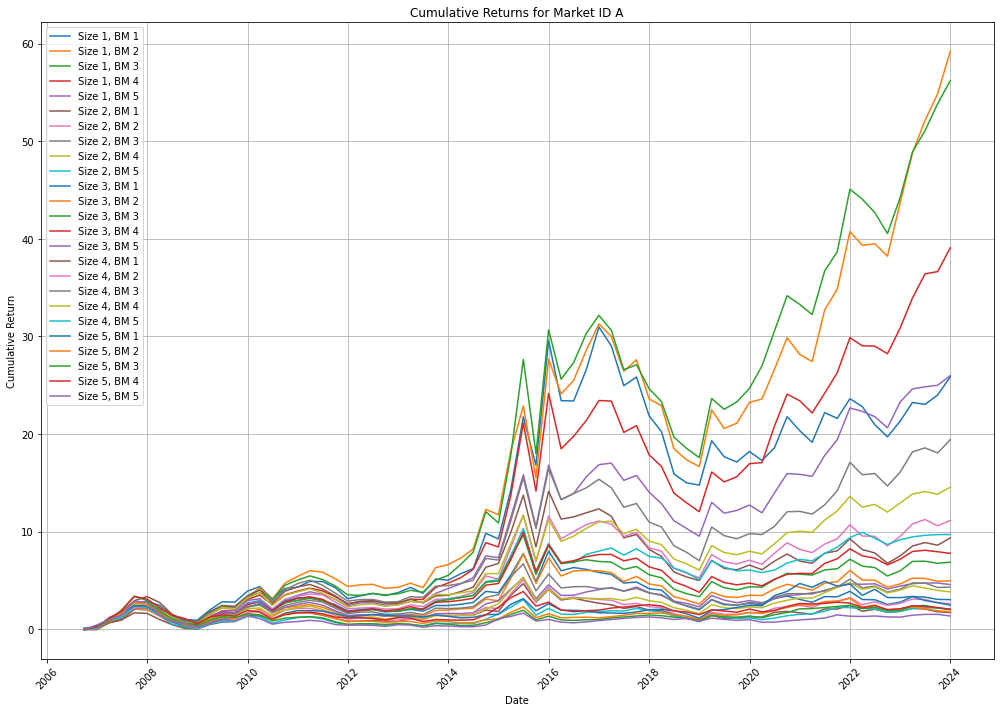

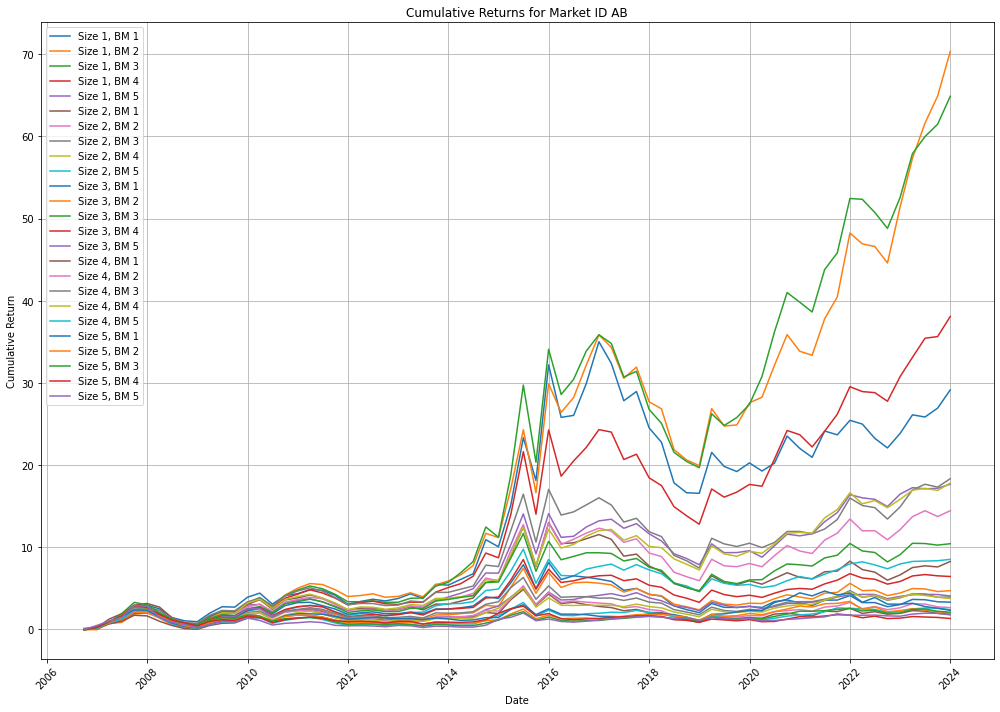

In [9]:
# Unique market identifiers
market_ids = quarterly_FF_25["市场标识_Mktflg"].unique()

for market_id in market_ids:
    plt.figure(figsize=(14, 10))
    
    # Filter data for the current market identifier
    market_data = quarterly_FF_25[quarterly_FF_25["市场标识_Mktflg"] == market_id]
    
    # Unique identifiers for 规模标识_Sizeflg and 账面市值比标识_BMflg
    size_ids = market_data["规模标识_Sizeflg"].unique()
    bm_ids = market_data["账面市值比标识_BMflg"].unique()
    
    for size_id in size_ids:
        for bm_id in bm_ids:
            # Filter data for the current size and BM
            portfolio_data = market_data[(market_data["规模标识_Sizeflg"] == size_id) & (market_data["账面市值比标识_BMflg"] == bm_id)]
            
            # Calculate cumulative returns
            portfolio_data = portfolio_data.sort_values("日期_Date")
            cumulative_returns = (1 + portfolio_data["资产组合月收益率__流通市值加权_Pmonret_tmv"]).cumprod() - 1
            
            # Plotting
            plt.plot(portfolio_data["日期_Date"], cumulative_returns, label=f"Size {size_id}, BM {bm_id}")
    
    plt.title(f"Cumulative Returns for Market ID {market_id}")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return")
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## Fama French 3 factor

Get quarterly FF3 factor with risk free rate

In [73]:
file_path = r'E:\behavioral finance\data\Momentum.xls'
df = pd.read_excel(file_path)
# Ensure the Date column is in datetime format
df['日期_Date'] = pd.to_datetime(df['日期_Date'])

# Setting the date as the index
df.set_index('日期_Date', inplace=True)
# A function to calculate quarterly returns
def quarterly_returns(group):
    # Converting monthly returns to "1 + monthly return" format
    group['Mom_12M'] = 1 + group['12个月惯性因子_流通市值加权()_MomFac_12M_TMV']#/100
    # Resampling to quarterly, calculating the product (compounded return), then subtracting 1
    quarterly = group.resample('Q').prod() - 1
    
    return quarterly
# Grouping by market, size, and book-to-market ratio, then applying the function
quarterly_mom = df.groupby(['市场标识_MktFlg' ]).apply(quarterly_returns)

# Resetting index if necessary
quarterly_mom.reset_index(inplace=True)
quarterly_mom = quarterly_mom.rename(columns={'市场标识_MktFlg': '市场标识_Mktflg'})
quarterly_mom = quarterly_mom.drop(columns=['12个月惯性因子_流通市值加权()_MomFac_12M_TMV'])

quarterly_mom

,市场标识_Mktflg,日期_Date,Mom_12M
0,A,2004-09-30,0.073549
1,A,2004-12-31,0.030323
2,A,2005-03-31,0.105015
3,A,2005-06-30,0.014346
4,A,2005-09-30,-0.057460
...,...,...,...
232,B,2023-03-31,0.040953
233,B,2023-06-30,0.029806
234,B,2023-09-30,0.026700
235,B,2023-12-31,0.014514


In [75]:
# Define the path to your Excel file
file_path = r'E:\behavioral finance\data\FF_3f.xls'
df = pd.read_excel(file_path)
df = df[df['交易所标识_Exchflg']==0]
df=df.drop(columns=['交易所标识_Exchflg' ])
# Ensure the Date column is in datetime format
df['日期_Date'] = pd.to_datetime(df['日期_Date'])

# Setting the date as the index
df.set_index('日期_Date', inplace=True)

# A function to calculate quarterly returns
def quarterly_returns(group):
    # Converting monthly returns to "1 + monthly return" format
    group['市场溢酬因子__流通市值加权_Rmrf_tmv'] = 1 + group['市场溢酬因子__流通市值加权_Rmrf_tmv']#/100
    group['市值因子__流通市值加权_Smb_tmv'] = 1 + group['市值因子__流通市值加权_Smb_tmv']#/100
    group['账面市值比因子__流通市值加权_Hml_tmv'] = 1 + group['账面市值比因子__流通市值加权_Hml_tmv']#/100
    # Resampling to quarterly, calculating the product (compounded return), then subtracting 1
    quarterly = group.resample('Q').prod() - 1
    
    return quarterly
# Grouping by market, size, and book-to-market ratio, then applying the function
quarterly_FF_3f = df.groupby(['市场标识_Mktflg' ]).apply(quarterly_returns)

# Resetting index if necessary
quarterly_FF_3f.reset_index(inplace=True)

quarterly_FF_3f = pd.merge(quarterly_mom, quarterly_FF_3f, on=['市场标识_Mktflg', '日期_Date'], how='inner')

file_path = r'E:\behavioral finance\data\rf.xls'
rf = pd.read_excel(file_path) 
 # Step 1: Convert `年份_Year` and `季度()_Qtr` in `rf` to datetime to match `日期_Date` in `quarterly_FF_3f`.
rf['日期_Date'] = rf.apply(lambda row: pd.Period(f"{int(row['年份_Year'])}Q{int(row['季度()_Qtr'])}").end_time.floor('D'), axis=1)
# Step 2: Duplicate `rf` for each type of `市场标识_Mktflg` present in `quarterly_FF_3f` if necessary.
# For simplicity, let's assume `市场标识_Mktflg` in `quarterly_FF_3f` has values 'A' and 'B'. This part may need adjustment based on actual data.
rf_a = rf.copy()
rf_a['市场标识_Mktflg'] = 'A'  # Assuming 'A' is one of the market flags
rf_b = rf.copy()
rf_b['市场标识_Mktflg'] = 'B'  # Assuming 'B' is the other market flag
rf_ab = rf.copy()
rf_ab['市场标识_Mktflg'] = 'AB'  # Assuming 'B' is the other market flag


# Combine the duplicated `rf` rows back into a single DataFrame.
rf_combined = pd.concat([rf_a, rf_b])
rf_combined = pd.concat([rf_combined, rf_ab])
# Step 3: Merge `rf_combined` with `quarterly_FF_3f` on `日期_Date` and `市场标识_Mktflg`.
merged_data = pd.merge(quarterly_FF_3f, rf_combined, on=['日期_Date', '市场标识_Mktflg'], how='left')

# Selecting and renaming the relevant column to include in the final DataFrame.
quarterly_FF_3f = merged_data[['市场标识_Mktflg', '日期_Date', '市场溢酬因子__流通市值加权_Rmrf_tmv', '市值因子__流通市值加权_Smb_tmv', '账面市值比因子__流通市值加权_Hml_tmv', 'Mom_12M','季无风险收益率()_QtrRFRet']]
quarterly_FF_3f.rename(columns={'季无风险收益率()_QtrRFRet': 'Risk_Free_Rate'}, inplace=True)

# Now `quarterly_data` contains the quarterly returns, grouped as requested
quarterly_FF_3f.head()

C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_12884/722904994.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  quarterly_FF_3f.rename(columns={'季无风险收益率()_QtrRFRet': 'Risk_Free_Rate'}, inplace=True)


,市场标识_Mktflg,日期_Date,市场溢酬因子__流通市值加权_Rmrf_tmv,市值因子__流通市值加权_Smb_tmv,账面市值比因子__流通市值加权_Hml_tmv,Mom_12M,Risk_Free_Rate
0,A,2006-09-30,-0.003901,0.034742,-0.044415,0.039298,0.006098
1,A,2006-12-31,0.293388,-0.221660,0.010147,0.155325,0.006796
2,A,2007-03-31,0.469059,0.239935,0.077554,-0.688797,0.007076
3,A,2007-06-30,0.297602,-0.111057,-0.056276,0.432469,0.007465
4,A,2007-09-30,0.444073,0.034447,0.089837,-0.027937,0.008229


### Plot 3 factor cumulative return 

<Axes: >

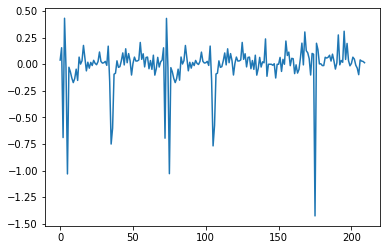

In [77]:
quarterly_FF_3f['Mom_12M'].plot()

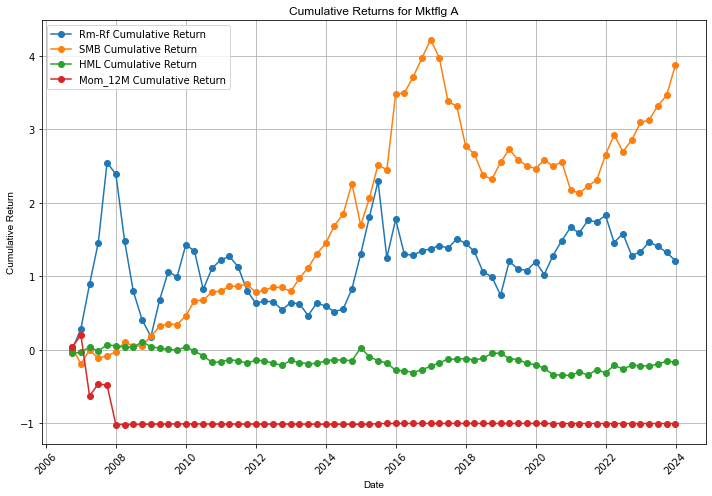

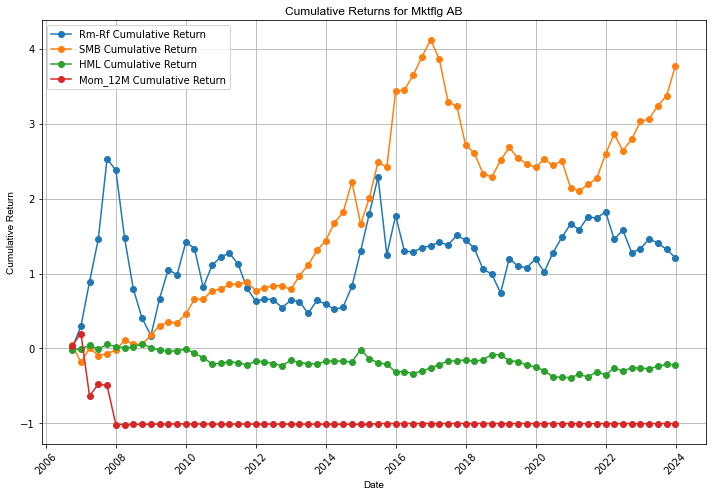

In [76]:
def plot_cumulative_returns(df, mktflg):
    # Filter DataFrame for the current 市场标识_Mktflg
    df_filtered = df[df["市场标识_Mktflg"] == mktflg].copy()  # Use .copy() to avoid SettingWithCopyWarning
    
    # Calculate cumulative returns using .loc for safe DataFrame modification
    df_filtered.loc[:, "市场溢酬因子_cum"] = (1 + df_filtered["市场溢酬因子__流通市值加权_Rmrf_tmv"]).cumprod() - 1
    df_filtered.loc[:, "市值因子_cum"] = (1 + df_filtered["市值因子__流通市值加权_Smb_tmv"]).cumprod() - 1
    df_filtered.loc[:, "账面市值比因子_cum"] = (1 + df_filtered["账面市值比因子__流通市值加权_Hml_tmv"]).cumprod() - 1
    df_filtered.loc[:, "Mom_12M_cum"] = (1 + df_filtered["Mom_12M"]).cumprod() - 1
    # Plotting
    plt.figure(figsize=(10, 7))
    plt.plot(df_filtered["日期_Date"], df_filtered["市场溢酬因子_cum"], label="Rm-Rf Cumulative Return", marker='o')
    plt.plot(df_filtered["日期_Date"], df_filtered["市值因子_cum"], label="SMB Cumulative Return", marker='o')
    plt.plot(df_filtered["日期_Date"], df_filtered["账面市值比因子_cum"], label="HML Cumulative Return", marker='o')
    plt.plot(df_filtered["日期_Date"], df_filtered["Mom_12M_cum"], label="Mom_12M Cumulative Return", marker='o')
    # Title and labels with handling for non-English characters
    plt.title(f"Cumulative Returns for Mktflg {mktflg}", fontname="Arial Unicode MS")
    plt.xlabel("Date", fontname="Arial Unicode MS")
    plt.ylabel("Cumulative Return", fontname="Arial Unicode MS")
    
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # If you're encountering issues with non-English characters in matplotlib, consider updating the rcParams as follows:
    # plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # or another appropriate font that supports Chinese characters
    # plt.rcParams['axes.unicode_minus'] = False  # This will handle the minus sign correctly

    plt.show()

# List of unique 市场标识_Mktflg in the DataFrame
mktflgs = ['A','AB']

# Plot cumulative returns for each 市场标识_Mktflg
for mktflg in mktflgs:
    plot_cumulative_returns(quarterly_FF_3f, mktflg)


### Merge lagged HS factor into 3 factor with rf

In [12]:
quarterly_FF_3f['日期_Date'] = pd.to_datetime(quarterly_FF_3f['日期_Date'])

# For 'df_hhi' and 'df_numTop', correctly convert the index or existing '日期_Date' to datetime.
# If '日期_Date' is already a column but incorrectly typed, convert it.
df_hhi['日期_Date'] = pd.to_datetime(df_hhi.index).floor('D')
df_numTop['日期_Date'] = pd.to_datetime(df_numTop.index).floor('D')

# If the index is being used directly and it's not already datetime typed,
# first convert the index to a datetime column.
# Assuming the index is already correctly set to datetime, just ensure it's used as a column.
df_hhi.reset_index(inplace=True, drop=True)
df_hhi['日期_Date'] = pd.to_datetime(df_hhi['日期_Date'])

df_numTop.reset_index(inplace=True, drop=True)
df_numTop['日期_Date'] = pd.to_datetime(df_numTop['日期_Date'])

# Now, attempt the merge again.
merged_data_hhi = pd.merge(quarterly_FF_3f, df_hhi, on='日期_Date', how='left')
merged_data_final = pd.merge(merged_data_hhi, df_numTop, on='日期_Date', how='left')


C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_12884/4154681538.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  quarterly_FF_3f['日期_Date'] = pd.to_datetime(quarterly_FF_3f['日期_Date'])


In [13]:
df_hhi

,HS2,日期_Date
0,0.037306,2004-06-30
1,0.037792,2004-09-30
2,0.039068,2004-12-31
3,0.040853,2005-03-31
4,0.046835,2005-06-30
...,...,...
74,0.008223,2022-12-31
75,0.007896,2023-03-31
76,0.007270,2023-06-30
77,0.007862,2023-09-30


In [78]:
''' I finally decided not to evaluate the performance using lagged data'''
# Lagging HS1 and HS2 by 1 quarter
df_hhi_lagged = df_hhi.copy()
df_numTop_lagged = df_numTop.copy()

# Assuming 'HS1' and 'HS2' are column names in df_hhi and df_numTop respectively. Adjust if your column names are different.
df_hhi_lagged['HS2_lagged'] = df_hhi['HS2'].shift(-1)
df_numTop_lagged['HS1_lagged'] = df_numTop['HS1'].shift(-1)

# Dropping the original HS1 and HS2 columns to avoid confusion, if necessary.
# df_hhi_lagged.drop(['HS1'], axis=1, inplace=True)
# df_numTop_lagged.drop(['HS2'], axis=1, inplace=True)

# Merging lagged data into quarterly_FF_3f
merged_data_hhi = pd.merge(quarterly_FF_3f, df_hhi_lagged[['日期_Date', 'HS2_lagged']], on='日期_Date', how='left')
merged_data_final = pd.merge(merged_data_hhi, df_numTop_lagged[['日期_Date', 'HS1_lagged']], on='日期_Date', how='left')

# Rename the lagged columns back to HS1 and HS2 if that's required
merged_data_final.rename(columns={'HS1_lagged': 'HS1', 'HS2_lagged': 'HS2'}, inplace=True)
merged_data_final = merged_data_final.dropna()
merged_data_final.tail()  # Display


,市场标识_Mktflg,日期_Date,市场溢酬因子__流通市值加权_Rmrf_tmv,市值因子__流通市值加权_Smb_tmv,账面市值比因子__流通市值加权_Hml_tmv,Mom_12M,Risk_Free_Rate,HS2,HS1
204,B,2022-09-30,-0.055181,0.024820,-0.042343,-0.036339,0.004331,0.008223,0.135951
205,B,2022-12-31,-0.000841,0.003963,0.019164,-0.097811,0.005020,0.007896,0.132022
206,B,2023-03-31,0.031822,-0.067084,-0.027651,0.040953,0.006027,0.007270,0.129381
207,B,2023-06-30,-0.068014,-0.035856,-0.019544,0.029806,0.005743,0.007862,0.126243
208,B,2023-09-30,-0.077041,0.033557,0.067447,0.026700,0.005278,0.007628,0.122366


### Mean, std of factors

In [80]:

# Initialize a dictionary to hold the results
stats_results = {}

# Get the unique market identifiers
market_identifiers = ['A', 'AB'] #quarterly_FF_3f['市场标识_Mktflg'].unique()

# Loop over each market identifier to calculate and store statistics
for market_id in market_identifiers:
    # Filter the DataFrame for the current market identifier
    market_data = merged_data_final[merged_data_final['市场标识_Mktflg'] == market_id]
    market_data=market_data[['市场溢酬因子__流通市值加权_Rmrf_tmv',  '市值因子__流通市值加权_Smb_tmv','账面市值比因子__流通市值加权_Hml_tmv','Mom_12M','HS1','HS2']]
    
    # Calculate mean and std for each factor column and store in a dict
    market_stats = {
        'Mean': market_data.mean(),
        'StdDev': market_data.std(),
        # T-statistic calculation: mean divided by (std / sqrt(n))
        'T-Statistic': market_data.mean() / (market_data.std() / np.sqrt(market_data.count()))
    }

    # Add the calculated stats to the results dict
    stats_results[market_id] = pd.DataFrame(market_stats)

# Now `stats_results` holds the stats for each market. To print them in a good shape:
for market, stats_df in stats_results.items():
    print(f"Statistics for Market {market}:")
    print(stats_df[['Mean', 'StdDev', 'T-Statistic']], "\n")


Statistics for Market A:
                             Mean    StdDev  T-Statistic
市场溢酬因子__流通市值加权_Rmrf_tmv  0.024361  0.160742     1.258900
市值因子__流通市值加权_Smb_tmv     0.025431  0.085220     2.478789
账面市值比因子__流通市值加权_Hml_tmv -0.000690  0.060565    -0.094675
Mom_12M                 -0.028767  0.210124    -1.137208
HS1                      0.208734  0.085783    20.212365
HS2                      0.014273  0.009152    12.955016 

Statistics for Market AB:
                             Mean    StdDev  T-Statistic
市场溢酬因子__流通市值加权_Rmrf_tmv  0.024262  0.160072     1.259016
市值因子__流通市值加权_Smb_tmv     0.025029  0.083968     2.475978
账面市值比因子__流通市值加权_Hml_tmv -0.001689  0.059532    -0.235617
Mom_12M                 -0.028667  0.210090    -1.133449
HS1                      0.208734  0.085783    20.212365
HS2                      0.014273  0.009152    12.955016 



In [16]:
market_identifiers

['A', 'AB']

In [81]:
# Assuming 'df' is a pandas DataFrame with stock market data including two markets denoted by '市场标识_Mktflg'
# The columns '市场溢酬因子__流通市值加权_Rmrf_tmv', '市值因子__流通市值加权_Smb_tmv', '账面市值比因子__流通市值加权_Hml_tmv' 
# are the factors for which we need to calculate the correlation matrix.

# Let's assume 'A' and 'B' are the two market identifiers in '市场标识_Mktflg'
market_A_data = merged_data_final[merged_data_final['市场标识_Mktflg'] == 'A']
market_B_data = merged_data_final[merged_data_final['市场标识_Mktflg'] == 'AB']

# Select only the factor columns for correlation matrix calculation
factors = ['市场溢酬因子__流通市值加权_Rmrf_tmv', '市值因子__流通市值加权_Smb_tmv', '账面市值比因子__流通市值加权_Hml_tmv','Mom_12M','HS1','HS2']
market_A_factors = market_A_data[factors]
market_B_factors = market_B_data[factors]

# Calculate correlation matrices for each market
correlation_matrix_A = market_A_factors.corr()
correlation_matrix_B = market_B_factors.corr()

# Combine the correlation matrices for reporting
correlation_matrices = {
    'Market A Correlation Matrix': correlation_matrix_A,
    'Market AB Correlation Matrix': correlation_matrix_B
}

correlation_matrices


{'Market A Correlation Matrix':                          市场溢酬因子__流通市值加权_Rmrf_tmv  市值因子__流通市值加权_Smb_tmv  \
 市场溢酬因子__流通市值加权_Rmrf_tmv                 1.000000              0.139909   
 市值因子__流通市值加权_Smb_tmv                    0.139909              1.000000   
 账面市值比因子__流通市值加权_Hml_tmv                -0.007903             -0.274537   
 Mom_12M                                 0.022861             -0.414694   
 HS1                                     0.259365             -0.061701   
 HS2                                     0.250213             -0.021408   
 
                          账面市值比因子__流通市值加权_Hml_tmv   Mom_12M       HS1       HS2  
 市场溢酬因子__流通市值加权_Rmrf_tmv                -0.007903  0.022861  0.259365  0.250213  
 市值因子__流通市值加权_Smb_tmv                   -0.274537 -0.414694 -0.061701 -0.021408  
 账面市值比因子__流通市值加权_Hml_tmv                 1.000000  0.059666 -0.040256 -0.019051  
 Mom_12M                                 0.059666  1.000000 -0.056378 -0.130101  
 HS1                            

In [82]:
correlation_matrices['Market AB Correlation Matrix']

,市场溢酬因子__流通市值加权_Rmrf_tmv,市值因子__流通市值加权_Smb_tmv,账面市值比因子__流通市值加权_Hml_tmv,Mom_12M,HS1,HS2
市场溢酬因子__流通市值加权_Rmrf_tmv,1.000000,0.138920,-0.067608,0.020910,0.259269,0.250470
市值因子__流通市值加权_Smb_tmv,0.138920,1.000000,-0.347663,-0.416421,-0.059388,-0.017556
账面市值比因子__流通市值加权_Hml_tmv,-0.067608,-0.347663,1.000000,0.108847,-0.050590,-0.026501
Mom_12M,0.020910,-0.416421,0.108847,1.000000,-0.059260,-0.132975
HS1,0.259269,-0.059388,-0.050590,-0.059260,1.000000,0.973754
HS2,0.250470,-0.017556,-0.026501,-0.132975,0.973754,1.000000


### Market Trends

C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_12884/1382405317.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  market_B_data['Market_Return'] = market_B_data['市场溢酬因子__流通市值加权_Rmrf_tmv'] + market_B_data['Risk_Free_Rate']
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_12884/1382405317.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  market_B_data['Cumulative_Return'] = (1 + market_B_data['Market_Return']).cumprod()


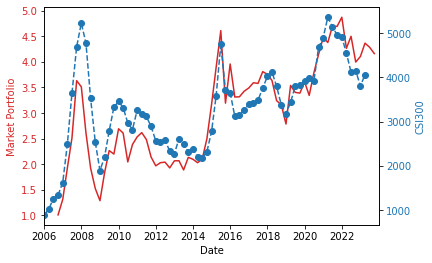

In [19]:
# Calculate the market return by summing the two columns
market_B_data['Market_Return'] = market_B_data['市场溢酬因子__流通市值加权_Rmrf_tmv'] + market_B_data['Risk_Free_Rate']

# Calculate the cumulative return
market_B_data['Cumulative_Return'] = (1 + market_B_data['Market_Return']).cumprod()

# Plotting
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('Date')
ax1.set_ylabel('Market Portfolio', color=color)
ax1.plot(market_B_data['日期_Date'], market_B_data['Cumulative_Return'], color=color)
ax1.tick_params(axis='y', labelcolor=color)

# Create a second y-axis for the hs300_quarterly data
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('CSI300', color=color)
ax2.plot(hs300_quarterly.index, hs300_quarterly, color=color, marker='o', linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)
plt.xlim(pd.Timestamp('2006-01-01'), pd.Timestamp('2023-12-31'))  # Adjust the x-axis to cover the extended date range

plt.show()

In [40]:
market_A_data

,市场标识_Mktflg,日期_Date,市场溢酬因子__流通市值加权_Rmrf_tmv,市值因子__流通市值加权_Smb_tmv,账面市值比因子__流通市值加权_Hml_tmv,Risk_Free_Rate,HS2,HS1,HS_orth
0,A,2006-09-30,-0.003901,0.034742,-0.044415,0.006098,0.042324,0.424807,0.028453
1,A,2006-12-31,0.293388,-0.221660,0.010147,0.006796,0.032996,0.394046,0.014890
2,A,2007-03-31,0.469059,0.239935,0.077554,0.007076,0.030675,0.369565,0.010066
3,A,2007-06-30,0.297602,-0.111057,-0.056276,0.007465,0.033851,0.371994,0.015685
4,A,2007-09-30,0.444073,0.034447,0.089837,0.008229,0.034114,0.369565,0.013862
...,...,...,...,...,...,...,...,...,...
64,A,2022-09-30,-0.116095,0.042642,0.063199,0.004331,0.008223,0.135951,-0.004049
65,A,2022-12-31,0.022191,0.062265,-0.003995,0.005020,0.007896,0.132022,-0.006347
66,A,2023-03-31,0.057625,0.008485,-0.010510,0.006027,0.007270,0.129381,-0.007478
67,A,2023-06-30,-0.024149,0.046470,0.039839,0.005743,0.007862,0.126243,-0.005721


In [48]:
model = sm.OLS(market_A_data['HS2'], market_A_data['市场溢酬因子__流通市值加权_Rmrf_tmv']).fit()
# Extracting the residuals
market_A_data['HS_orth'] = model.resid


C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_12884/3605561741.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  market_A_data['HS_orth'] = model.resid


## A share FF3-report alpha and t-stats

In [86]:
FF_25_A = quarterly_FF_25[quarterly_FF_25['市场标识_Mktflg']=='A']

def FF3_reg(df):
    # Merging the dataframes on '日期_Date'
    data = pd.merge(df, market_A_data, on='日期_Date', how='inner')
    
    Y = data['资产组合月收益率__流通市值加权_Pmonret_tmv']-data['Risk_Free_Rate']
    X = sm.add_constant(data.loc[:,['市场溢酬因子__流通市值加权_Rmrf_tmv', '市值因子__流通市值加权_Smb_tmv', '账面市值比因子__流通市值加权_Hml_tmv','Mom_12M']])
    
    FF = sm.OLS(Y, X).fit(cov_type='HC3')
    
    # Accessing the intercept (alpha) and its t-value
    alpha = FF.params[0]
    alpha_t = FF.tvalues[0]
    
    return pd.Series({'Alpha': FF.params[0], 'Alpha_t': FF.tvalues[0],
                     'Rm-Rf': FF.params[1], 'Rm-Rf_t': FF.tvalues[1],
                     'Smb': FF.params[2], 'Smb_t': FF.tvalues[2],
                     'Hml': FF.params[3], 'Hml_t': FF.tvalues[3],
                      'Mom': FF.params[4],'Mom_t': FF.tvalues[4],
                     })

# Apply the function and store the results
ff3result = FF_25_A.groupby(['规模标识_Sizeflg','账面市值比标识_BMflg']).apply(FF3_reg)

ff3result_reset = ff3result.reset_index()

def HS_reg(df):
    # Merging the dataframes on '日期_Date'
    data = pd.merge(df, market_A_data, on='日期_Date', how='inner')
    
    Y = data['资产组合月收益率__流通市值加权_Pmonret_tmv']-data['Risk_Free_Rate']
    X = sm.add_constant(data.loc[:,['市场溢酬因子__流通市值加权_Rmrf_tmv', '市值因子__流通市值加权_Smb_tmv', '账面市值比因子__流通市值加权_Hml_tmv','HS2']])
    
    FF = sm.OLS(Y, X).fit(cov_type='HC3')
    
    
    return pd.Series({'a': FF.params[0], 't(a)': FF.tvalues[0],
                      'b': FF.params[1],     't(b)': FF.tvalues[1],     
                     's': FF.params[2],     't(s)': FF.tvalues[2], 
                      'h': FF.params[3],     't(h)': FF.tvalues[3], 
                      'hs': FF.params[4],     't(hs)': FF.tvalues[4], 
                     })

# Apply the function and store the results
HSresult = FF_25_A.groupby(['规模标识_Sizeflg','账面市值比标识_BMflg']).apply(HS_reg)

HSresult_reset = HSresult.reset_index()

C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_12884/475496184.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha = FF.params[0]
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_12884/475496184.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha_t = FF.tvalues[0]
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_12884/475496184.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return pd.Series({'Alpha': FF.params[0], 'A

C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_12884/475496184.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha = FF.params[0]
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_12884/475496184.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha_t = FF.tvalues[0]
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_12884/475496184.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return pd.Series({'Alpha': FF.params[0], 'A

C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_12884/475496184.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return pd.Series({'a': FF.params[0], 't(a)': FF.tvalues[0],
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_12884/475496184.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return pd.Series({'a': FF.params[0], 't(a)': FF.tvalues[0],
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_12884/475496184.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by 

In [87]:
ff3result_reset

,规模标识_Sizeflg,账面市值比标识_BMflg,Alpha,Alpha_t,Rm-Rf,Rm-Rf_t,Smb,Smb_t,Hml,Hml_t,Mom,Mom_t
0,1,1,-0.001562,-0.248233,1.039210,23.257772,1.316746,12.106928,-0.113299,-0.998143,-0.080189,-1.407013
1,1,2,0.012012,2.093506,1.036148,22.153467,1.384366,15.655047,-0.120071,-0.998543,0.030635,0.536798
2,1,3,0.010791,1.780530,1.006230,21.641186,1.351879,15.495100,-0.212155,-1.667902,-0.042854,-0.938432
3,1,4,0.007516,1.385204,1.040588,23.782447,1.255529,15.050645,-0.191944,-1.477786,-0.009481,-0.205398
4,1,5,0.004594,0.866095,1.008876,18.198709,1.115502,12.972327,-0.042044,-0.288921,0.005867,0.160476
5,2,1,-0.010243,-2.589567,1.098367,28.913425,1.066063,18.744138,-0.237434,-2.950280,-0.038749,-0.912335
6,2,2,-0.006579,-1.520865,1.053583,30.527022,1.094606,18.435992,-0.331205,-3.101567,0.012776,0.693881
7,2,3,0.000106,0.022859,1.044674,30.536142,1.072613,14.504147,-0.235987,-1.981491,-0.015747,-0.840096
8,2,4,-0.003370,-0.666214,1.111369,22.634873,1.064600,10.046281,-0.057100,-0.427237,-0.003449,-0.093037
9,2,5,-0.007734,-1.221150,1.051038,21.105170,1.057900,8.429904,0.367536,2.271318,0.003447,0.089650


In [63]:

def HS_reg(df):
    # Merging the dataframes on '日期_Date'
    data = pd.merge(df, market_A_data, on='日期_Date', how='inner')
    
    Y = data['资产组合月收益率__流通市值加权_Pmonret_tmv']-data['Risk_Free_Rate']
    X = sm.add_constant(data.loc[:,['市场溢酬因子__流通市值加权_Rmrf_tmv', '市值因子__流通市值加权_Smb_tmv',  'HS2']])
    
    FF = sm.OLS(Y, X).fit(cov_type='HC3')
    
    
    return pd.Series({'a': FF.params[0], 't(a)': FF.tvalues[0],
                      'b': FF.params[1],     't(b)': FF.tvalues[1],     
                     's': FF.params[2],     't(s)': FF.tvalues[2], 
                      'hs': FF.params[3],     't(hs)': FF.tvalues[3], 
                     })

# Apply the function and store the results
HSresult = FF_25_A.groupby(['规模标识_Sizeflg','账面市值比标识_BMflg']).apply(HS_reg)

HSresult_reset = HSresult.reset_index()

C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_12884/940336610.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return pd.Series({'a': FF.params[0], 't(a)': FF.tvalues[0],
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_12884/940336610.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return pd.Series({'a': FF.params[0], 't(a)': FF.tvalues[0],
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_12884/940336610.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by 

In [88]:
#print(HSresult_reset.iloc[:,[0,1,10,11]])
HSresult_reset

,规模标识_Sizeflg,账面市值比标识_BMflg,a,t(a),b,t(b),s,t(s),h,t(h),hs,t(hs)
0,1,1,-0.002200,-0.175336,1.029374,20.565341,1.404891,15.128189,-0.095862,-0.801502,0.066934,0.095490
1,1,2,0.026952,2.156921,1.055304,21.725145,1.343140,16.991154,-0.132329,-1.084249,-1.068261,-1.384165
2,1,3,0.026552,2.075250,1.017845,19.606851,1.390709,15.009515,-0.208969,-1.495278,-1.106740,-1.457060
3,1,4,0.028871,2.585797,1.061879,24.027696,1.254937,18.469869,-0.198043,-1.530990,-1.512594,-2.251774
4,1,5,0.017748,1.494389,1.023329,20.130029,1.102317,10.415106,-0.048312,-0.315126,-0.934878,-1.298177
5,2,1,-0.022267,-2.646583,1.081340,29.590415,1.114677,19.642520,-0.224546,-2.672363,0.863524,1.370355
6,2,2,0.003879,0.421515,1.066001,29.132181,1.075240,19.169143,-0.337927,-3.057129,-0.745455,-1.358043
7,2,3,-0.001859,-0.201122,1.040816,29.464263,1.090868,14.835104,-0.231862,-1.931761,0.143622,0.278164
8,2,4,-0.007733,-0.721007,1.106404,25.141811,1.070619,9.533007,-0.054699,-0.413607,0.310453,0.465750
9,2,5,-0.009992,-0.768036,1.049067,20.755252,1.055286,8.846568,0.367657,2.269534,0.159272,0.215858


## AB share FF3-report alpha and t-stats

In [24]:
FF_25_AB = quarterly_FF_25[quarterly_FF_25['市场标识_Mktflg']=='AB']

def FF3_reg(df):
    # Merging the dataframes on '日期_Date'
    data = pd.merge(df, market_B_data, on='日期_Date', how='inner')
    
    Y = data['资产组合月收益率__流通市值加权_Pmonret_tmv']-data['Risk_Free_Rate']
    X = sm.add_constant(data.loc[:,['市场溢酬因子__流通市值加权_Rmrf_tmv', '市值因子__流通市值加权_Smb_tmv', '账面市值比因子__流通市值加权_Hml_tmv']])
    
    FF = sm.OLS(Y, X).fit()
    
    # Accessing the intercept (alpha) and its t-value
    alpha = FF.params[0]
    alpha_t = FF.tvalues[0]
    
    return pd.Series({'Alpha': FF.params[0], 'Alpha_t': FF.tvalues[0]})

def HS_reg(df):
    # Merging the dataframes on '日期_Date'
    data = pd.merge(df, market_B_data, on='日期_Date', how='inner')
    
    Y = data['资产组合月收益率__流通市值加权_Pmonret_tmv']-data['Risk_Free_Rate']
    X = sm.add_constant(data.loc[:,['市场溢酬因子__流通市值加权_Rmrf_tmv', '市值因子__流通市值加权_Smb_tmv', '账面市值比因子__流通市值加权_Hml_tmv','HS2']])
    
    FF = sm.OLS(Y, X).fit()
    
    
    return pd.Series({'a': FF.params[0], 't(a)': FF.tvalues[0],
                      'b': FF.params[1],     't(b)': FF.tvalues[1],     
                     's': FF.params[2],     't(s)': FF.tvalues[2], 
                      'h': FF.params[3],     't(h)': FF.tvalues[3], 
                      'hs': FF.params[4],     't(hs)': FF.tvalues[4], 
                     })

# Apply the function and store the results
ff3result = FF_25_AB.groupby(['规模标识_Sizeflg','账面市值比标识_BMflg']).apply(FF3_reg)
# Apply the function and store the results
HSresult = FF_25_AB.groupby(['规模标识_Sizeflg','账面市值比标识_BMflg']).apply(HS_reg)
# ff3result now contains the alphas and their t-values for each group
# To enhance readability, you might want to reset the index
HSresult_reset = HSresult.reset_index()
# ff3result now contains the alphas and their t-values for each group
# To enhance readability, you might want to reset the index
ff3result_reset = ff3result.reset_index()

C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_12884/1712096667.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha = FF.params[0]
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_12884/1712096667.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha_t = FF.tvalues[0]
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_12884/1712096667.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return pd.Series({'Alpha': FF.params[0],

C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_12884/1712096667.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha = FF.params[0]
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_12884/1712096667.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha_t = FF.tvalues[0]
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_12884/1712096667.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return pd.Series({'Alpha': FF.params[0],

C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_12884/1712096667.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha_t = FF.tvalues[0]
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_12884/1712096667.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return pd.Series({'Alpha': FF.params[0], 'Alpha_t': FF.tvalues[0]})
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_12884/1712096667.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[p

C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_12884/1712096667.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return pd.Series({'a': FF.params[0], 't(a)': FF.tvalues[0],
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_12884/1712096667.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return pd.Series({'a': FF.params[0], 't(a)': FF.tvalues[0],
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_12884/1712096667.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value 

C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_12884/1712096667.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  's': FF.params[2],     't(s)': FF.tvalues[2],
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_12884/1712096667.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'h': FF.params[3],     't(h)': FF.tvalues[3],
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_12884/1712096667.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[p

In [25]:
print(ff3result_reset)

    规模标识_Sizeflg  账面市值比标识_BMflg     Alpha   Alpha_t
0              1              1 -0.000283 -0.043014
1              1              2  0.014179  2.560991
2              1              3  0.013059  2.168125
3              1              4  0.007047  1.309430
4              1              5  0.002649  0.527513
5              2              1 -0.011961 -2.786666
6              2              2 -0.003400 -0.702273
7              2              3 -0.000896 -0.190818
8              2              4 -0.000218 -0.048443
9              2              5 -0.008347 -1.759663
10             3              1 -0.017400 -3.495212
11             3              2 -0.014174 -2.611604
12             3              3 -0.003294 -0.756184
13             3              4 -0.010416 -2.038976
14             3              5 -0.012106 -3.187702
15             4              1 -0.014630 -2.301316
16             4              2 -0.014426 -2.672324
17             4              3 -0.010184 -2.038099
18          

In [26]:
print(HSresult_reset.iloc[:,[0,1,10,11]])

    规模标识_Sizeflg  账面市值比标识_BMflg        hs     t(hs)
0              1              1 -0.016307 -0.022773
1              1              2 -1.899219 -3.423888
2              1              3 -1.458277 -2.312487
3              1              4 -1.163861 -2.048290
4              1              5 -0.298986 -0.547639
5              2              1  0.589053  1.275131
6              2              2 -0.679852 -1.305522
7              2              3  0.187834  0.367628
8              2              4 -0.024159 -0.049226
9              2              5 -0.062275 -0.120480
10             3              1  0.119200  0.219797
11             3              2 -1.110917 -1.932289
12             3              3 -0.250322 -0.528447
13             3              4 -0.062099 -0.111554
14             3              5  0.397959  0.968560
15             4              1 -0.893218 -1.306333
16             4              2 -0.489858 -0.837205
17             4              3  0.058475  0.107394
18          